# WP1 Stage 04: DOS and projected DOS

Read-only post-processing of five completed ZnIn2S4 phases. This notebook calls shared scripts, validates raw results against accepted analysis, and exports five standalone selected near-edge PDOS figures. No calculation is launched; calculation files and accepted results are never rewritten.

Use the repository's isolated `.venv-wp1-plots` environment with NumPy, Matplotlib, pymatgen, nbformat, nbclient and ipykernel, plus an editable installation of the local CMW checkout (`python -m pip install -e /path/to/computational-modelling-workflow`, performed outside this notebook). The actual interpreter, packages, CMW module path and commit are recorded below.

Rerun with `execute_wp1_plot_notebook.py` from the repository root or this notebook's directory. Each execution uses a fresh kernel and one numerical thread. Together with the five band PDFs, these form the ten-file publication set. Element PDOS is opt-in diagnostic/SI output; standalone TDOS is redundant because element PDOS includes it. If the editable registration is hidden by macOS, launch with process-local `PYTHONPATH="/path/to/computational-modelling-workflow/src"`.

## Editable configuration

Set `ROOT_OVERRIDE` only if executing outside the repository. The common (-3, 3) eV window shows near-edge orbital character without deep Zn-d peaks controlling the scale. Each phase uses physical f.u.-normalized values with 7–8% rounded headroom above only the plotted curves inside this window. f.u. = one ZnIn2S4 formula unit. `OVERWRITE=True` replaces only this workflow's exact phase/kind filenames; unrelated files are untouched. One requested format produces one file, with PNG at 600 dpi only when explicitly selected. No CSV or cache export is enabled.

### Optional element-PDOS diagnostics

`ELEMENT_DIAGNOSTICS=False` keeps diagnostics off. To opt in, set it to `True` and provide a separate `DIAGNOSTIC_DIRECTORY`; its inventory is reported separately. Element PDOS retains TDOS/Zn/In/S, a configurable wider window, and the same adaptive-y algorithm. Element-PDOS PDFs are optional diagnostic/SI exports and are not included in the frozen ten-PDF publication set.

In [1]:
from pathlib import Path
import os
import sys

ROOT_OVERRIDE = None
PHASE_SELECTION = ["spinel", "alpha1", "beta", "IIa_prime", "IIb"]
REFERENCE = "vbm"  # same audited dense uniform-mesh VBM as the band notebook
ENERGY_LIMITS = (-3.0, 3.0)
OUTPUT_FORMAT = "pdf"  # one of pdf, svg, png
OUTPUT_DIRECTORY = None  # default: this results directory / figures
OVERWRITE = True
NORMALIZATION = "formula_unit"  # or "cell"
SELECTED_CHANNELS = ["S-p", "In-s", "S-s", "Zn-d", "Zn-s"]
ELEMENT_DIAGNOSTICS = False
ELEMENT_ENERGY_LIMITS = (-8.0, 4.0)
DIAGNOSTIC_DIRECTORY = None  # explicit separate directory required when enabled

# Task-local setup, before importing numerical/plotting libraries.
for name in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[name] = "1"
os.environ["PYTHONDONTWRITEBYTECODE"] = "1"
os.environ["MPLBACKEND"] = "Agg"
wp1_relative = Path("vasp/wp1_polymorph_polytype_benchmark")
candidates = [Path(ROOT_OVERRIDE).expanduser().resolve()] if ROOT_OVERRIDE else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
root = next((p for p in candidates if (p / wp1_relative / "structure/RAW_STRUCTURE_PROVENANCE.md").is_file()), None)
if root is None:
    raise RuntimeError("Run inside the repository or set ROOT_OVERRIDE explicitly")
sys.path.insert(0, str(root / wp1_relative / "script/wp1"))

## Environment and resolved scientific sources

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from wp1_electronic_plot_data import load_all, source_mapping, energy_window
from wp1_electronic_plot_style import RC, default_output, environment_summary, save_figure, display_figure
from plot_wp1_dos_pdos import FAMILIES, adaptive_y_limits, plot_dos

environment = environment_summary()
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(environment.items(), columns=["component", "actual version/location"]))
sources = source_mapping(root, PHASE_SELECTION)
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"phase": phase, "branch": branch, "source": str(path.relative_to(root))}
                          for phase, branches in sources.items() for branch, path in branches.items()]))

,component,actual version/location
0,Python,3.14.6
1,executable,/Users/liangze/Desktop/Imperial/Year 26-27/fyp/computational/.venv-wp1-plots/bin/python
2,numpy,2.5.3
3,matplotlib,3.11.1
4,pymatgen,2026.5.4
5,spglib,2.7.0
6,nbformat,5.11.1
7,nbclient,0.11.0
8,ipykernel,7.3.0
9,CMW module,/Users/liangze/Desktop/squiddy tools/computational-modelling-workflow/src/cmw/analysis/electronic.py


,phase,branch,source
0,spinel,dos,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/spinel
1,spinel,band,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/02_band/spinel
2,spinel,parent,vasp/wp1_polymorph_polytype_benchmark/calculation/03_static_scf/spinel
3,alpha1,dos,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/alpha1
4,alpha1,band,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/02_band/alpha1
5,alpha1,parent,vasp/wp1_polymorph_polytype_benchmark/calculation/03_static_scf/alpha1
6,beta,dos,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/beta
7,beta,band,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/02_band/beta
8,beta,parent,vasp/wp1_polymorph_polytype_benchmark/calculation/03_static_scf/beta
9,IIa_prime,dos,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/IIa_prime


## Validation and common energy reference

All ten Stage 04 branches must be completed fixed-density, nonmagnetic PBE outputs with the accepted cell, species order, dimensions and gaps. A material discrepancy raises an error before export. The exact reference source is retained for each phase. Parsing is sequential, and only required XML spectra/metadata are requested.

In [3]:
data = load_all(root, PHASE_SELECTION, REFERENCE)
window = energy_window(data, "dos", ENERGY_LIMITS)
output_directory = Path(OUTPUT_DIRECTORY).expanduser().resolve() if OUTPUT_DIRECTORY else default_output(root)
validation_columns = ["phase", "formula_units", "reference_mode", "reference_eV", "dos_kpoints", "band_kpoints", "bands", "primitive_cells", "uniform_gap_eV", "path_gap_eV", "validation"]
display(pd.DataFrame([d.summary for d in data])[validation_columns])
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"phase": d.summary["phase"], "reference_source": d.summary["reference_source"], "classification": d.summary["classification"]} for d in data]))
display(pd.DataFrame([{"phase": d.summary["phase"], "DOS coverage (eV)": d.dos_coverage, "band coverage (eV)": d.band_coverage} for d in data]))
print(f"Shared energy window: {window} eV; output: {OUTPUT_FORMAT}")
display(pd.DataFrame([{"phase": d.phase, "standalone PDOS limits": adaptive_y_limits(d, "selected_orbital_pdos", window, normalization=NORMALIZATION, selected=SELECTED_CHANNELS)} for d in data]))

,phase,formula_units,reference_mode,reference_eV,dos_kpoints,band_kpoints,bands,primitive_cells,uniform_gap_eV,path_gap_eV,validation
0,Spinel,8,vbm,4.179865,20,240,304,4,1.317947,1.314507,PASS
1,α₁,3,vbm,4.510352,202,280,112,3,0.304198,0.304197,PASS
2,β,1,vbm,4.533285,202,360,40,1,0.303118,0.303118,PASS
3,IIa′,2,vbm,4.163139,202,360,80,1,0.303574,0.298994,PASS
4,IIb,2,vbm,4.504881,148,360,80,1,0.278638,0.278638,PASS


,phase,reference_source,classification
0,Spinel,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/spinel/EIGENVAL,INDIRECT ON THE SAMPLED UNIFORM MESH
1,α₁,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/alpha1/EIGENVAL,DIRECT ON THE SAMPLED UNIFORM MESH
2,β,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/beta/EIGENVAL,AMBIGUOUS / NEAR-DEGENERATE
3,IIa′,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/IIa_prime/EIGENVAL,INDIRECT ON THE SAMPLED UNIFORM MESH
4,IIb,vasp/wp1_polymorph_polytype_benchmark/calculation/04_electronic_structure/01_dos_pdos/IIb/EIGENVAL,DIRECT ON THE SAMPLED UNIFORM MESH


,phase,DOS coverage (eV),band coverage (eV)
0,Spinel,"(-14.088546000000001, 6.6628549999999995)","(-14.088546000000001, 6.665667)"
1,α₁,"(-15.496621999999999, 4.5435229999999995)","(-15.496621999999999, 4.530747000000001)"
2,β,"(-15.45627, 5.128476999999999)","(-15.45627, 5.128476999999999)"
3,IIa′,"(-15.362354, 5.736045)","(-15.362354, 5.735516)"
4,IIb,"(-15.506012000000002, 5.096025999999999)","(-15.506012000000002, 5.096025999999999)"


Shared energy window: (-3.0, 3.0) eV; output: pdf


,phase,standalone PDOS limits
0,spinel,"(0.0, 8.69)"
1,alpha1,"(0.0, 6.73)"
2,beta,"(0.0, 6.78)"
3,IIa_prime,"(0.0, 6.38)"
4,IIb,"(0.0, 6.7700000000000005)"


## Standalone publication figures

Five selected near-edge orbital PDOS PDFs use the audited VBM reference, identical (-3, 3) eV windows and physical formula-unit normalization. Adaptive y limits use only displayed samples; no smoothing or peak normalization is applied. S-p, In-s, S-s, Zn-d and Zn-s are retained. Figures contain curves, axis labels and a legend, with no phase labels or subtitles. Each is saved once, displayed inline, then closed.

findfont: Failed to find font weight bold, now using 400.


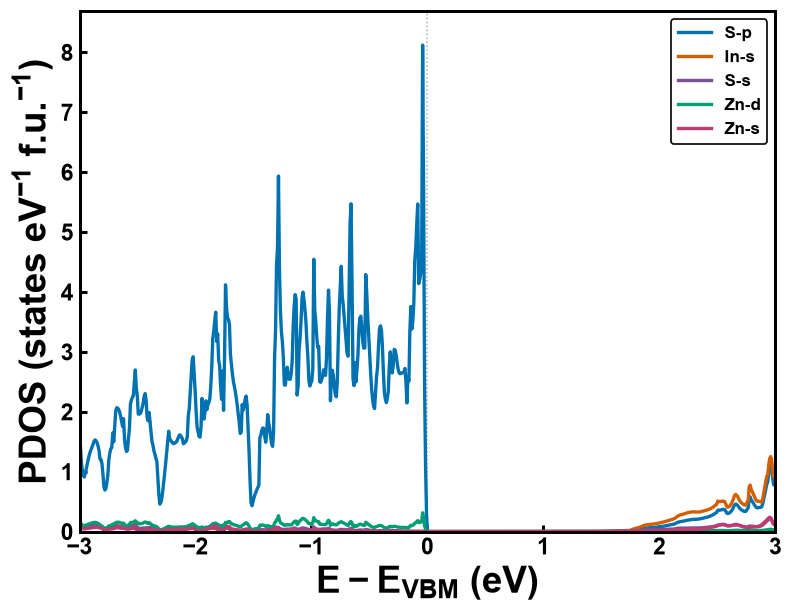

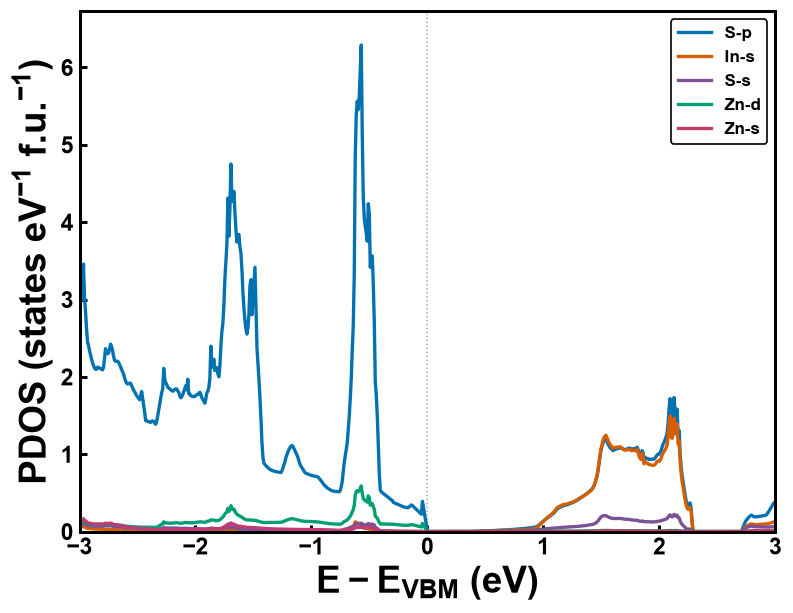

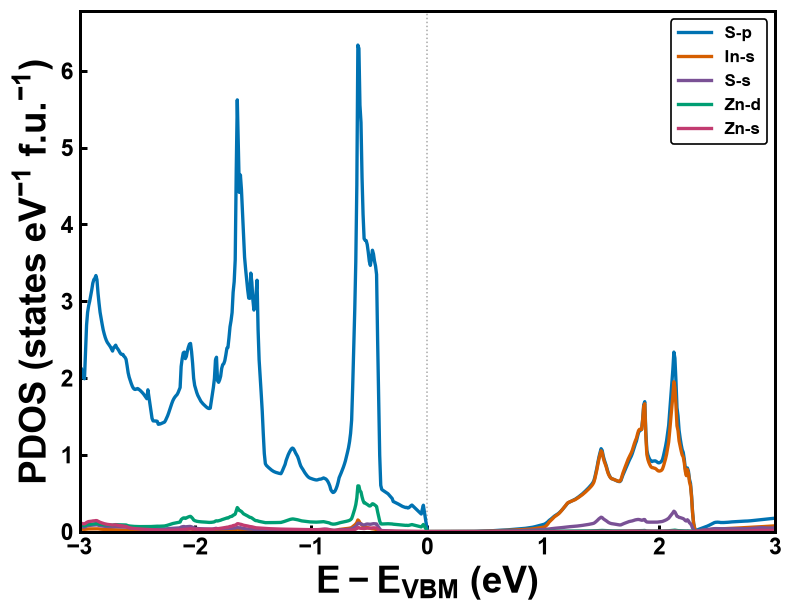

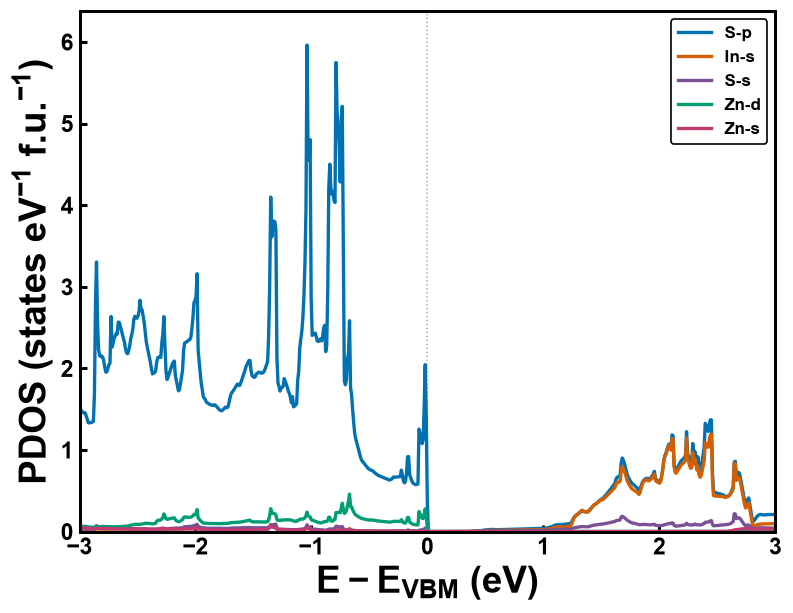

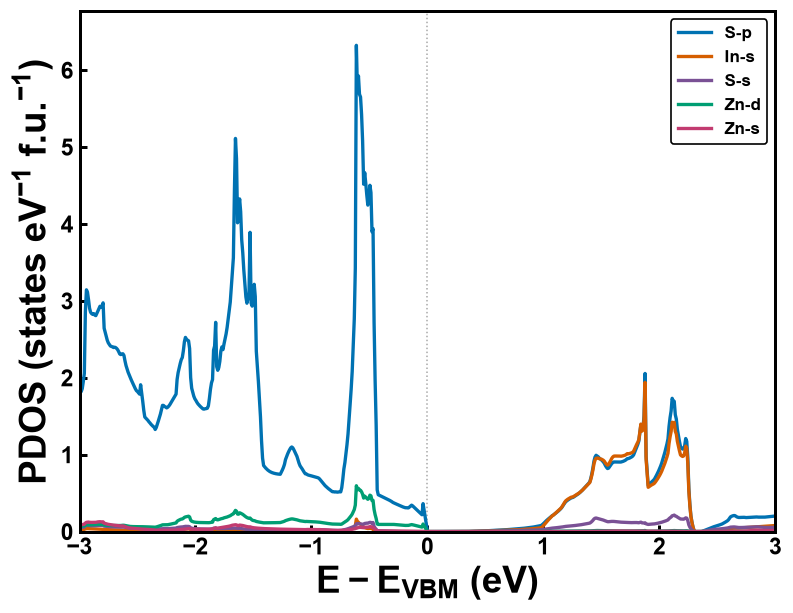

In [4]:
inventory = []
for phase in data:
    for kind in FAMILIES:
        fig, ax, metadata = plot_dos(phase, kind, window=window, normalization=NORMALIZATION, selected=SELECTED_CHANNELS)
        try:
            path = save_figure(fig, output_directory, phase.phase, kind, output_format=OUTPUT_FORMAT, overwrite=OVERWRITE)
            with mpl.rc_context(RC):
                display_figure(fig)
            inventory.append({"phase": phase.summary["phase"], "figure": path.name, "axes": len(fig.axes), "bytes": path.stat().st_size})
        finally:
            plt.close(fig)

diagnostic_inventory = []
if ELEMENT_DIAGNOSTICS:
    if DIAGNOSTIC_DIRECTORY is None:
        raise ValueError("Set a separate DIAGNOSTIC_DIRECTORY for opt-in element PDOS")
    diagnostic_directory = Path(DIAGNOSTIC_DIRECTORY).expanduser().resolve()
    if diagnostic_directory == output_directory.resolve():
        raise ValueError("Keep diagnostic exports separate from publication output")
    element_window = energy_window(data, "dos", ELEMENT_ENERGY_LIMITS)
    for phase in data:
        fig, _, _ = plot_dos(phase, "element_pdos", window=element_window, normalization=NORMALIZATION)
        try:
            path = save_figure(fig, diagnostic_directory, phase.phase, "element_pdos", output_format=OUTPUT_FORMAT, overwrite=OVERWRITE)
            display_figure(fig)
            diagnostic_inventory.append({"phase": phase.phase, "diagnostic figure": str(path)})
        finally:
            plt.close(fig)

## Interpretation and provenance limits

These are **PBE electronic structures on PBE+D3(BJ)-relaxed geometries**, from completed fixed-density ICHARG=11 evaluations. They are not HSE06, SOC-corrected, vacuum-aligned, or D3-corrected band gaps.

The phase-local audited **dense uniform-mesh sampled VBM** is applied exactly once to both DOS and band arrays by the shared loader. Neither the Line-mode E_F, path maximum nor a broadened DOS onset is used. Optional Fermi-reference mode remains available for diagnostics. Cross-phase energy zeros do not establish absolute band offsets.

Unchanged accepted numerical analysis: [electronic-structure report](ELECTRONIC_STRUCTURE_ANALYSIS.md), [summary](electronic_structure_summary.csv), [band edges](band_edges.csv), [integrated PDOS descriptors](pdos_band_edge_character.csv), and [path justification](KPOINTS_SELECTION_JUSTIFICATION.md). Current structures are checked against Stage 03. Fixed-density charge lineage relies on the accepted audit; this plotting workflow does not reread large CHGCAR/WAVECAR files.

Uniform-mesh and path-sampled gaps are separate finite-sampling results, not continuous-Brillouin-zone guarantees. Beta remains **ambiguous / near-degenerate**, with approximately 1.38 meV direct-indirect splitting in the accepted dense-mesh analysis. Folded spinel (4 primitive cells) and alpha1 (3 primitive cells) are retained; apparent folded extrema do not establish primitive-cell optical directness.

DOS uses the one physical ISPIN=1 channel, without doubling or mirroring. Every extensive curve is divided by the same verified formula-unit count by default (8, 3, 1, 2, 2). Projection sums use XML orbital labels and site species; their internal s/p/d closure is verified. PAW projections need not sum to TDOS and are not renormalized to do so. Selected channels are not a complete decomposition or exact atomic populations. Integrated band-edge percentages remain separate accepted analyses.

The XML grid and spectra are used without added broadening, smoothing, peak normalization or extrapolation. XML/DOSCAR comparisons propagate their printed precision, including the sum of four-decimal XML site-component rounding bounds. The default selected-PDOS range is -3 to +3 eV; deep states outside it do not determine ymax. Each phase has 7–8% rounded headroom over the largest displayed channel value, with identical units and no peak rescaling. Element diagnostics default to -8 to +4 eV and use the same adaptive-y policy; a common-y CLI option is explicit only.

Implementation integrity check (10 September 2026): a bounded SHA-256 before/after inventory covered 108 consumed files, without reading large restart files. All 107 calculation/accepted-result files were byte-identical. The sole changed item was the pre-existing analysis Python script, independently committed with reorganized input paths in d8e2365 after directory-move commit 5ad0c0e during this task; the plotting workflow did not modify it or the scientific repository index. Plotting deliverables were uncommitted at that initial integrity check and are frozen separately from the raw calculations. CMW provenance above records the separately authorized local-only utility commit.

Visual/export notes: STIX sans math uses explicit regular glyph selection to avoid this Matplotlib version's bold-glyph fallback recursion; one benign font-weight fallback notice may be emitted, but final glyphs were rendered and inspected. Band labels are horizontal, with separate display-only gaps at disconnected branches and unchanged physical path metrics. Strong peaks and folded crossings are not removed. All exports are single-page, single-panel PDFs under the default configuration.

Primary technical references: [VASP DOSCAR](https://vasp.at/wiki/DOSCAR), [VASP EFERMI](https://vasp.at/wiki/EFERMI), [VASP DFT band workflow](https://vasp.at/wiki/Band-structure_calculation_using_DFT), [SeeK-path original-cell conventions](https://seekpath.readthedocs.io/en/latest/maindoc.html). Actual paths and phase results come from local calculations, not substituted documentation examples.

## Output inventory

No raw arrays, CSV exports, JSON/YAML sidecars or raster preview collection are written by this notebook. Inline images are notebook displays, not a second external figure set.

This inventory contains exactly five selected-PDOS publications. The band notebook owns the other five publication PDFs. Element-PDOS diagnostics are not included in the frozen canonical figure set. The obsolete standalone TDOS PDFs were removed after validation of the ten-PDF set.

In [5]:
display(pd.DataFrame(inventory))
assert len(inventory) == len(PHASE_SELECTION)
assert all(item["axes"] == 1 and item["bytes"] > 1000 for item in inventory)
assert not plt.get_fignums()
print(f"{len(inventory)} standalone {OUTPUT_FORMAT.upper()} figures; all validation gates passed.")
if diagnostic_inventory:
    display(pd.DataFrame(diagnostic_inventory))

,phase,figure,axes,bytes
0,Spinel,spinel_pbe_selected_orbital_pdos.pdf,1,30929
1,α₁,alpha1_pbe_selected_orbital_pdos.pdf,1,28424
2,β,beta_pbe_selected_orbital_pdos.pdf,1,27418
3,IIa′,IIa_prime_pbe_selected_orbital_pdos.pdf,1,29301
4,IIb,IIb_pbe_selected_orbital_pdos.pdf,1,27386


5 standalone PDF figures; all validation gates passed.
